
H2-C8
Pre zeros : 2.26%
Post zeros: 43.15%


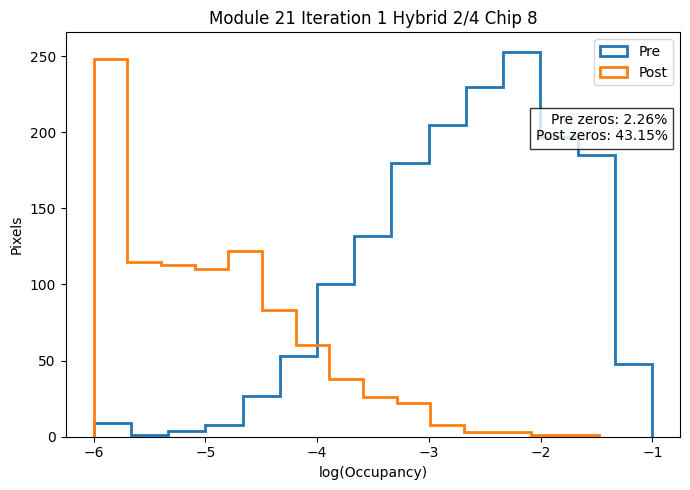


H2-C9
Pre zeros : 2.68%
Post zeros: 25.30%


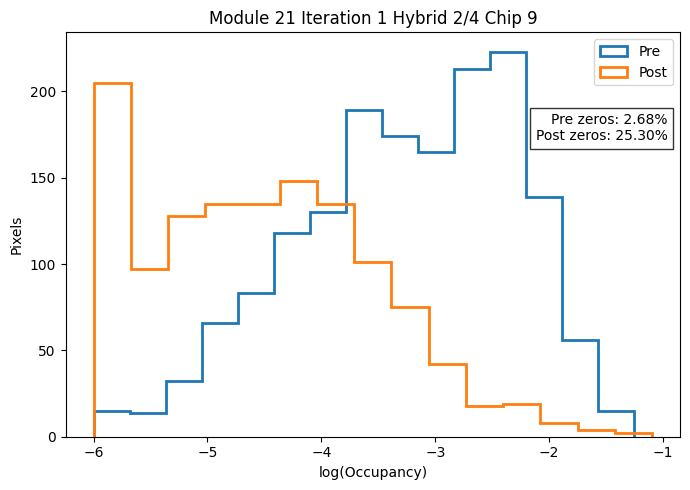


H2-C10
Pre zeros : 80.36%
Post zeros: 57.98%


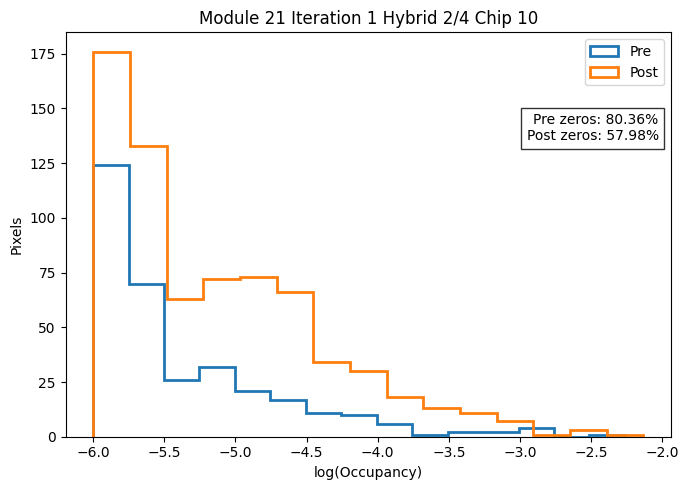


H2-C11
Pre zeros : 85.89%
Post zeros: 85.00%


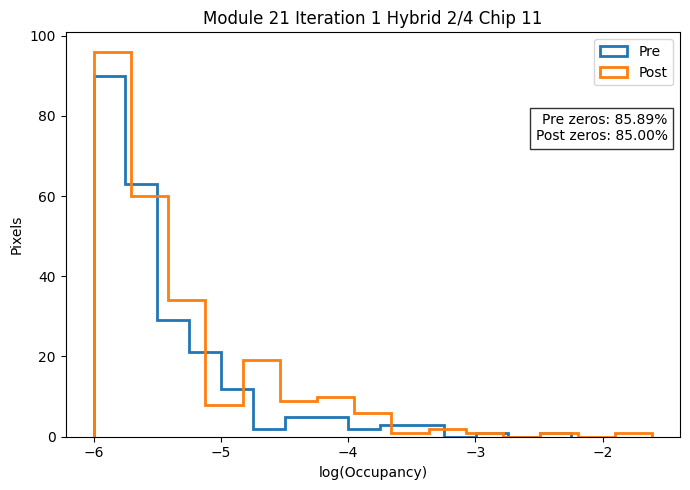


H2-C12
Pre zeros : 80.12%
Post zeros: 75.24%


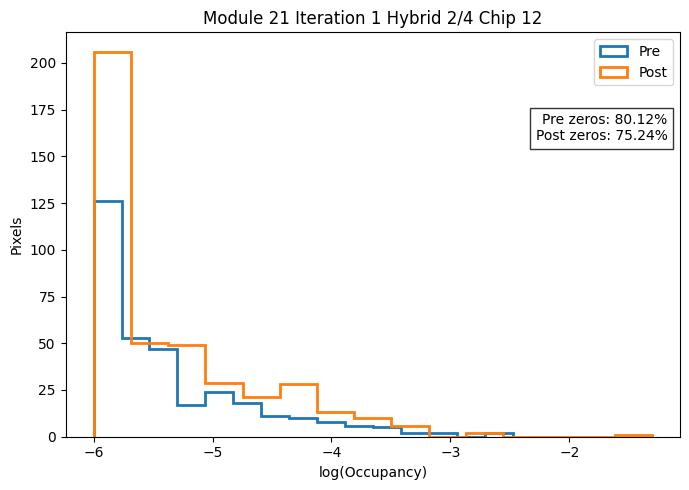


H2-C13
Pre zeros : 83.04%
Post zeros: 79.46%


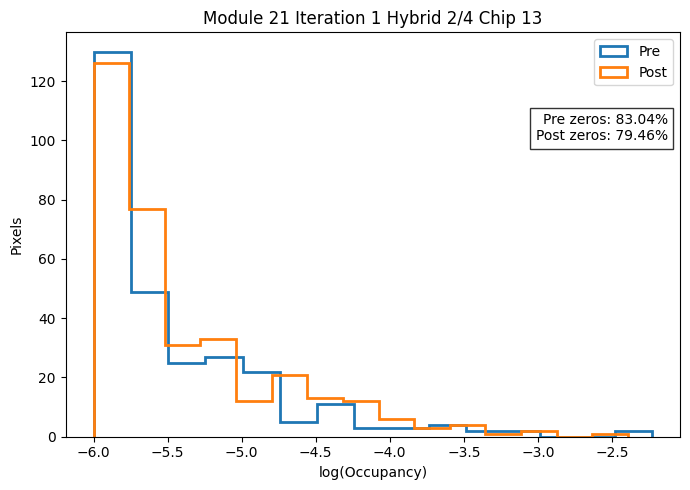


H2-C14
Pre zeros : 81.37%
Post zeros: 71.90%


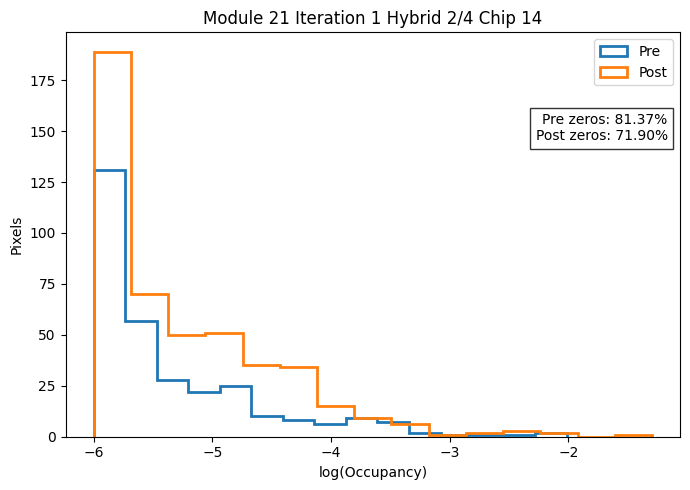


H2-C15
Pre zeros : 86.79%
Post zeros: 92.68%


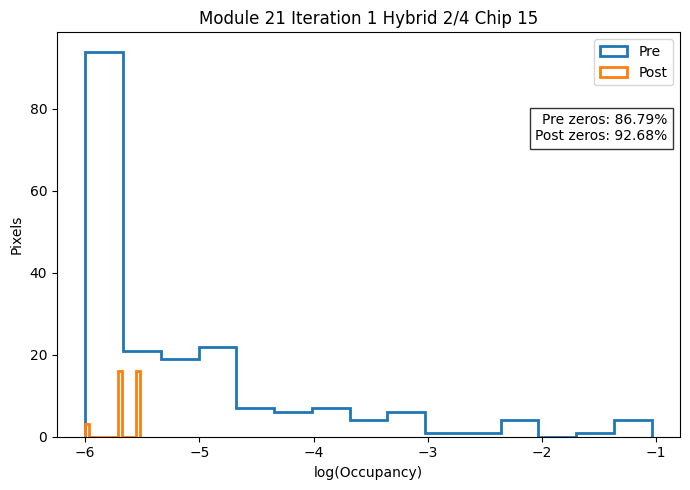


H3-C8
Pre zeros : 84.35%
Post zeros: 92.68%


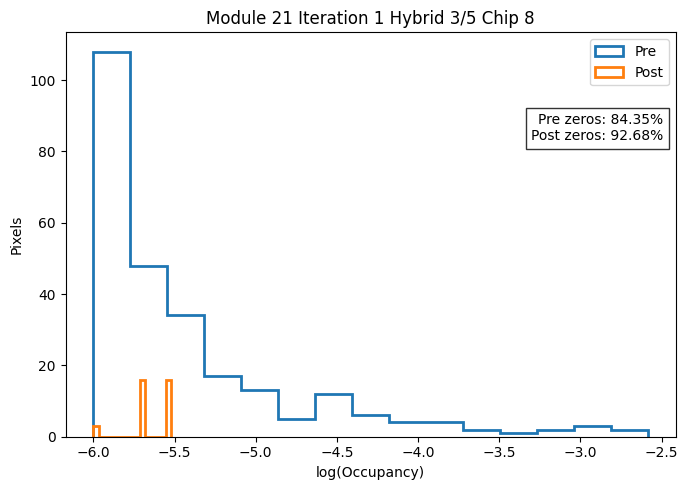


H3-C9
Pre zeros : 78.10%
Post zeros: 54.23%


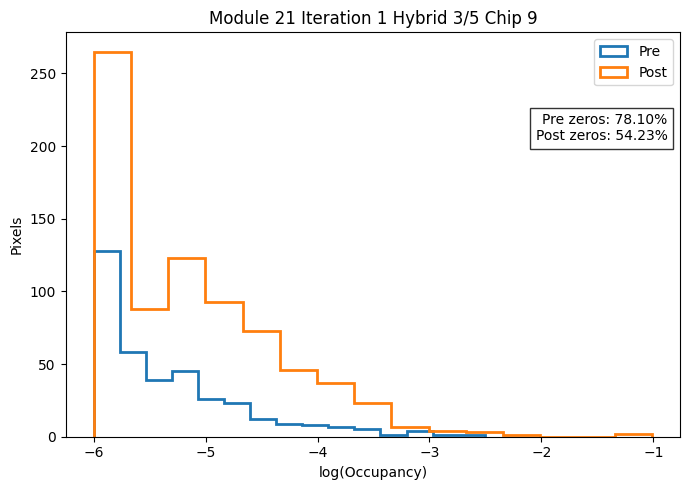


H3-C10
Pre zeros : 80.00%
Post zeros: 75.89%


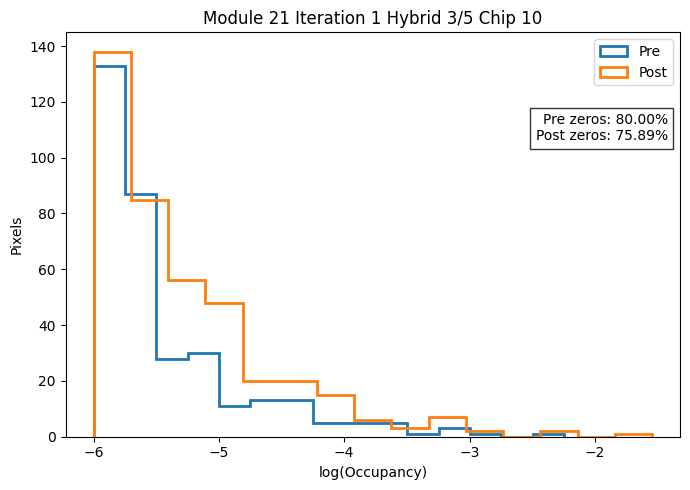


H3-C11
Pre zeros : 81.49%
Post zeros: 71.55%


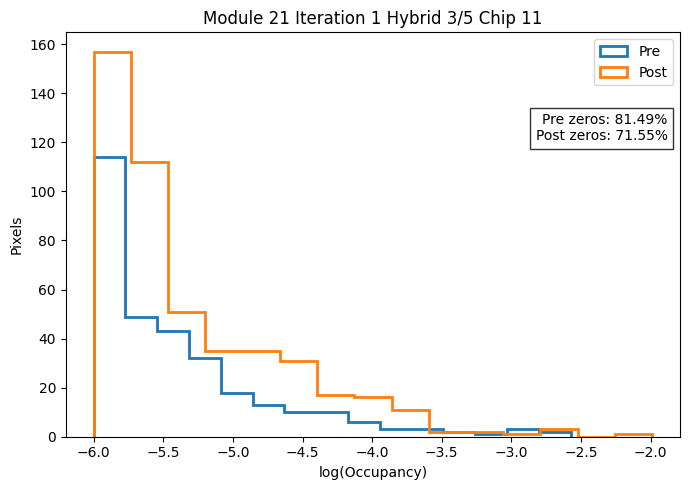


H3-C12
Pre zeros : 73.33%
Post zeros: 83.15%


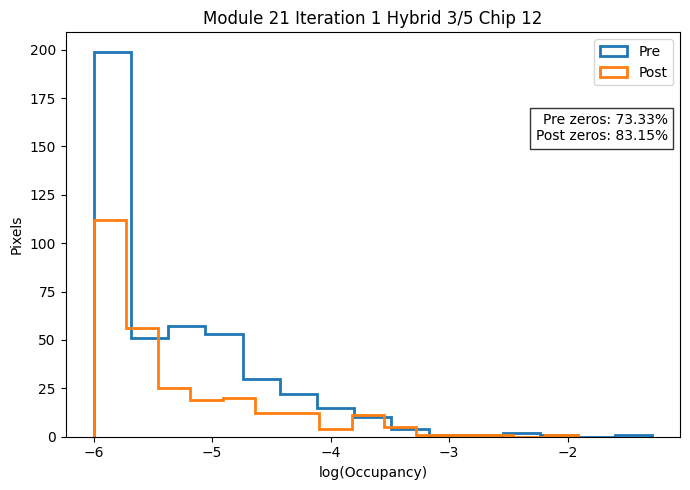


H3-C13
Pre zeros : 87.98%
Post zeros: 78.63%


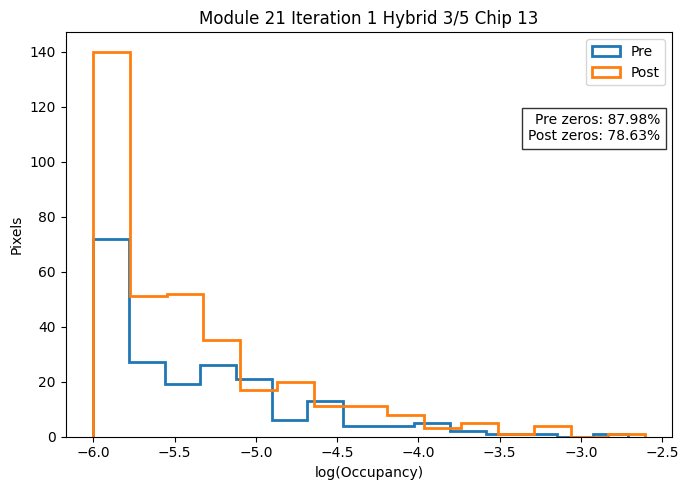


H3-C14
Pre zeros : 83.27%
Post zeros: 76.67%


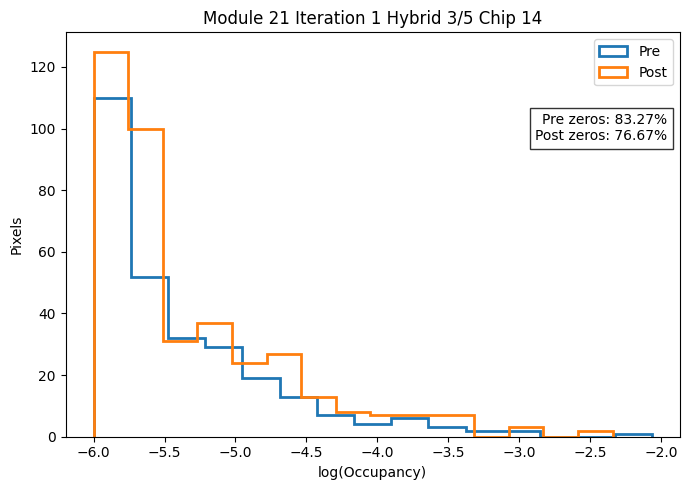


H3-C15
Pre zeros : 1.25%
Post zeros: 7.62%


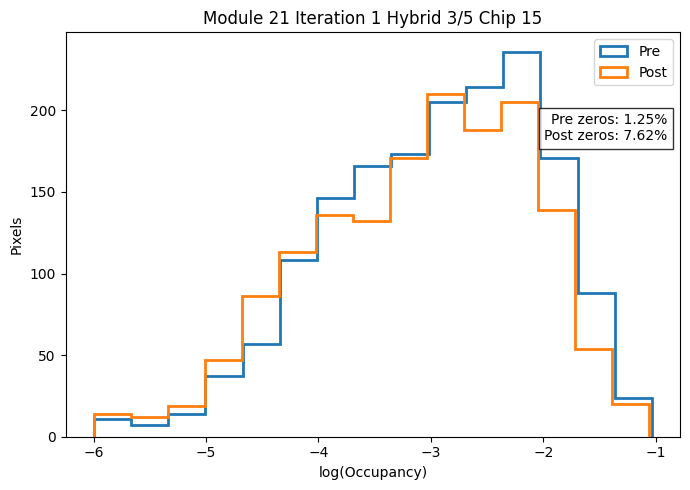

In [95]:
#Mod 21, Iteration 1

import uproot
import numpy as np
import matplotlib.pyplot as plt

#2, 119, 0.1

EDGE_LOW = 2
EDGE_HIGH = 119
THRESHOLD = 0.1

root_pre = "PS_16_FNL-10021_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"
root_post = (
    "/home/ekimrey/QPT_before_irradiation/"
    "post_irradiation_for_Emerson/"
    "TrackerHistos/TrackerHistos_42.root"
)


def read_th2(root_file, path):
    with uproot.open(root_file) as f:
        values, _, _ = f[path].to_numpy(flow=False)
    return np.array(values)


def make_pre_histpath(hybrid, chip):
    return (
        f"Detector/Board_0/OpticalGroup_1/Hybrid_{hybrid}/MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


def make_post_histpath(hybrid, chip):
    return (
        f"Iteration_1_PSfullTest_2026-03-12_17-23-21/"
        f"Detector/Board_0/OpticalGroup_2/Hybrid_{hybrid}/MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )


def process_chip(root_file, path):
    values = read_th2(root_file, path)
    values = values[:, EDGE_LOW:EDGE_HIGH]

    flat = values.flatten()

    zero_pct = 100 * np.sum(flat == 0) / len(flat)

    nonzero = flat[flat > 0]

    clean = nonzero[nonzero < THRESHOLD]

    return clean, zero_pct


labels = []

for pre_hybrid, post_hybrid in zip([2,3],[4,5]):
    for chip in range(8,16):

        labels.append(f"H{pre_hybrid}-C{chip}")

        clean_pre, zero_pre = process_chip(
            root_pre,
            make_pre_histpath(pre_hybrid, chip)
        )

        clean_post, zero_post = process_chip(
            root_post,
            make_post_histpath(post_hybrid, chip)
        )

        print(f"\nH{pre_hybrid}-C{chip}")
        print(f"Pre zeros : {zero_pre:.2f}%")
        print(f"Post zeros: {zero_post:.2f}%")

        plt.figure(figsize=(7,5))

        plt.hist(np.log10(clean_pre),
                 bins=15,
                 histtype="step",
                 linewidth=2,
                 label="Pre")
        
        plt.hist(np.log10(clean_post),
            bins=15,
            histtype="step",
            linewidth=2,
            label = "Post")

        plt.xlabel("log(Occupancy)")
        plt.ylabel("Pixels")
        plt.title(f"Module 21 Iteration 1 Hybrid {pre_hybrid}/{post_hybrid} Chip {chip}")

        plt.text(
            0.98,0.8,
            f"Pre zeros: {zero_pre:.2f}%\nPost zeros: {zero_post:.2f}%",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            bbox=dict(facecolor="white",alpha=0.8)
        )
        
        plt.legend()
        plt.tight_layout()
        plt.show()

        
        
#fig.savefig(f"Mod21_I1_H{pre_hybrid}{post_hybrid}_Ch{chip}.png", dpi=150)
#fig.savefig(f"Mod21_I1_H{pre_hybrid}{post_hybrid}_Ch{chip}.pdf")
        




H2-C8
Pre zeros : 2.26%
Post zeros: 23.81%


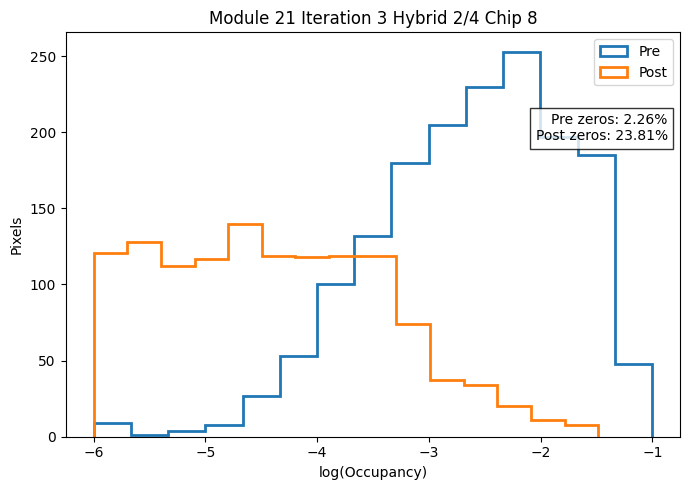


H2-C9
Pre zeros : 2.68%
Post zeros: 23.87%


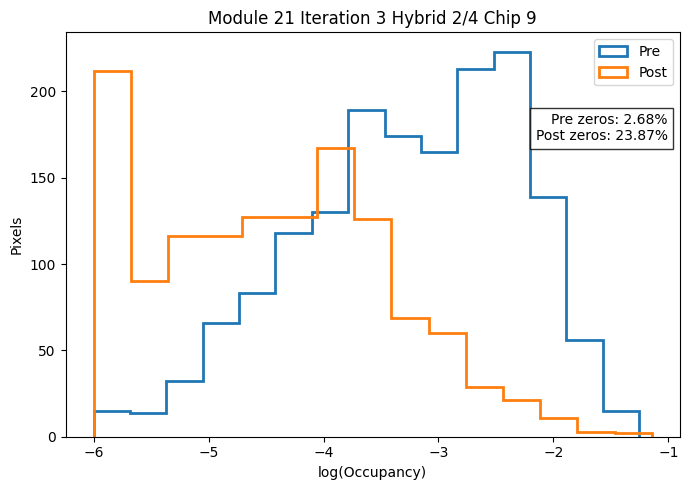


H2-C10
Pre zeros : 80.36%
Post zeros: 71.13%


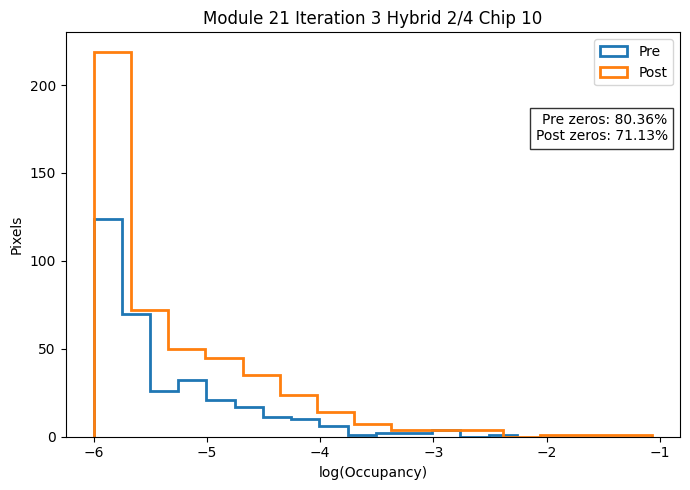


H2-C11
Pre zeros : 85.89%
Post zeros: 80.60%


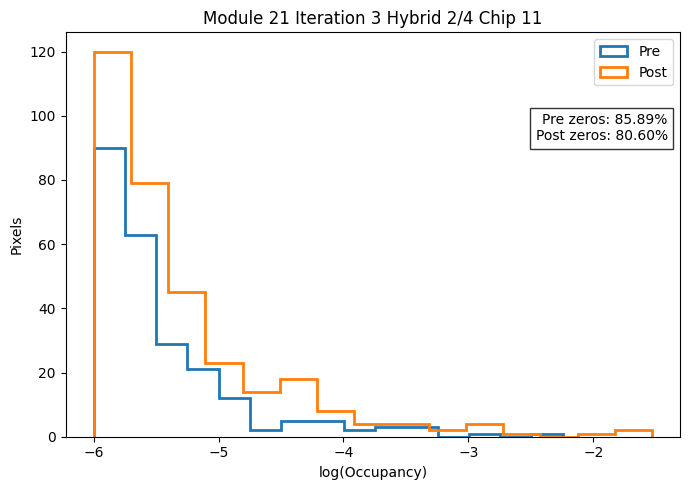


H2-C12
Pre zeros : 80.12%
Post zeros: 56.19%


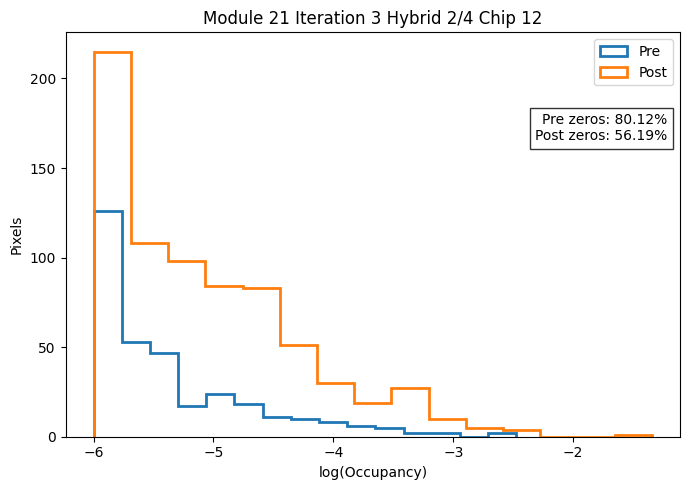


H2-C13
Pre zeros : 83.04%
Post zeros: 78.57%


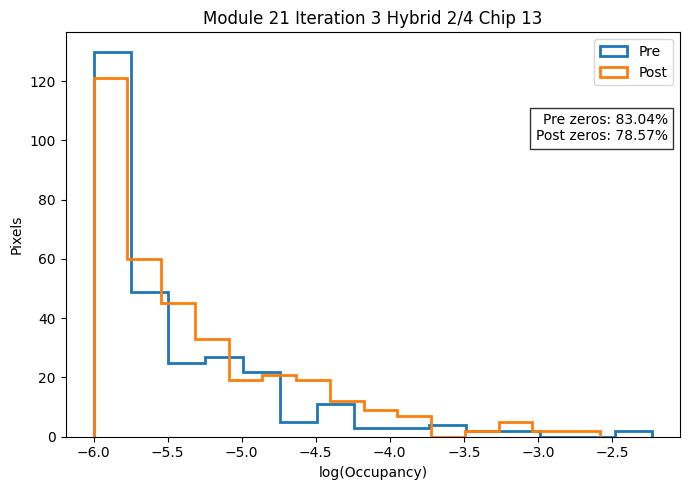


H2-C14
Pre zeros : 81.37%
Post zeros: 83.75%


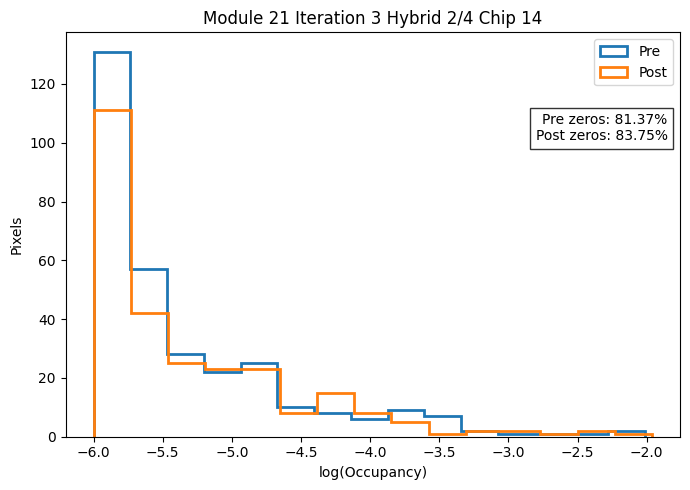


H2-C15
Pre zeros : 86.79%
Post zeros: 81.85%


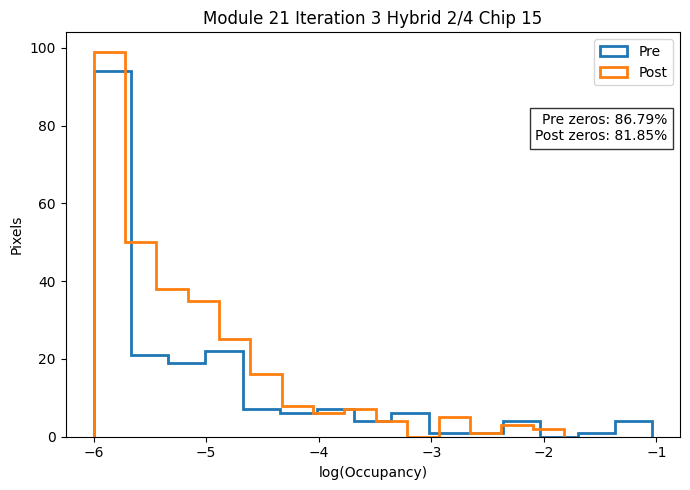


H3-C8
Pre zeros : 84.35%
Post zeros: 64.40%


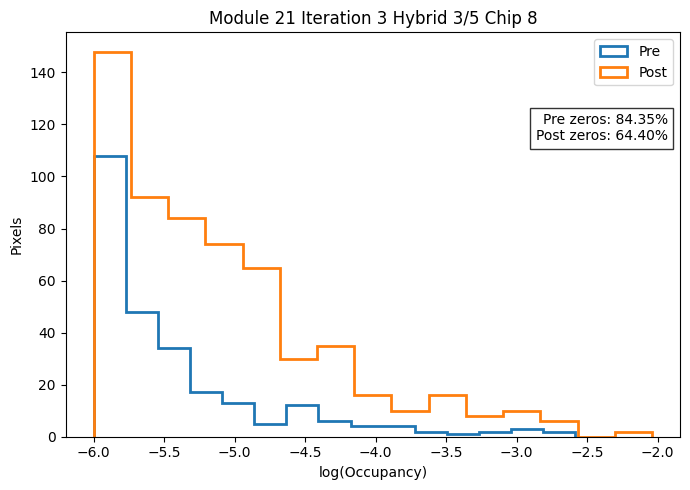


H3-C9
Pre zeros : 78.10%
Post zeros: 72.68%


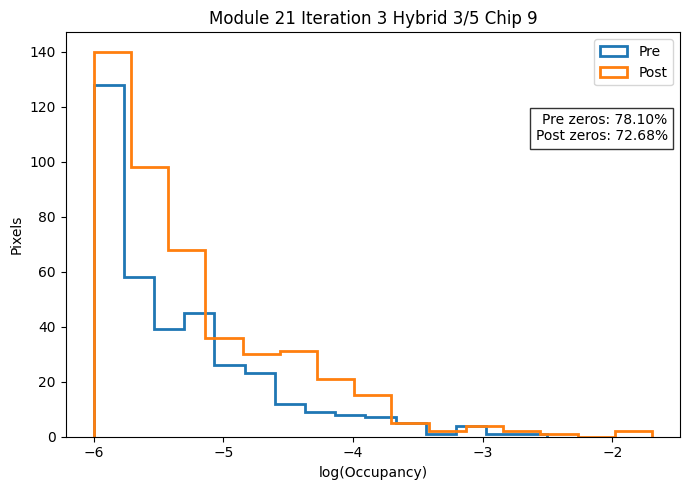


H3-C10
Pre zeros : 80.00%
Post zeros: 70.77%


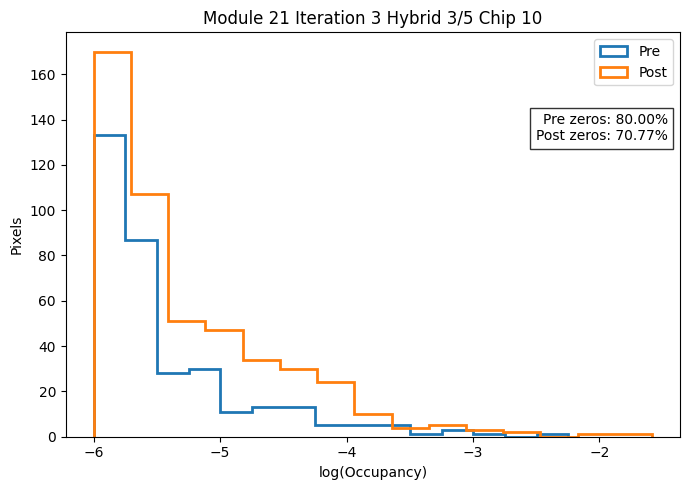


H3-C11
Pre zeros : 81.49%
Post zeros: 70.48%


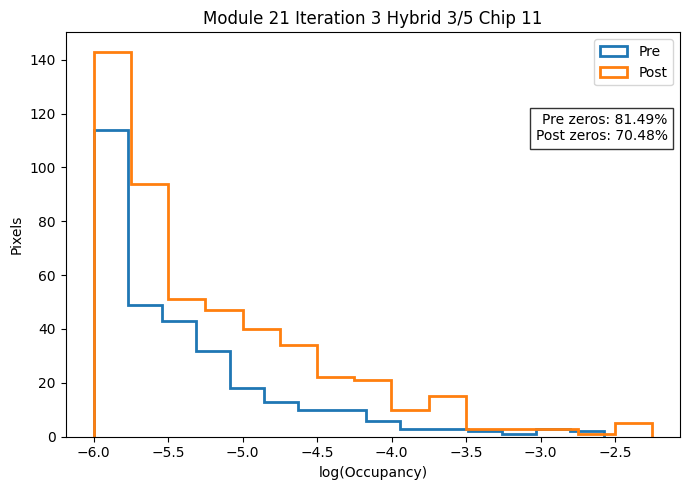


H3-C12
Pre zeros : 73.33%
Post zeros: 67.08%


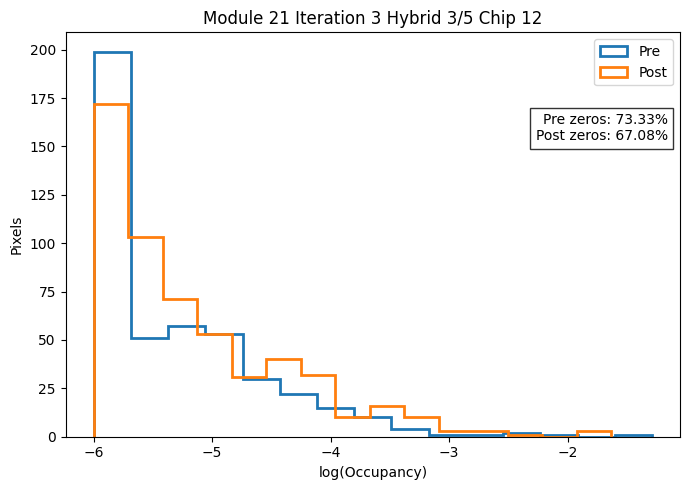


H3-C13
Pre zeros : 87.98%
Post zeros: 77.74%


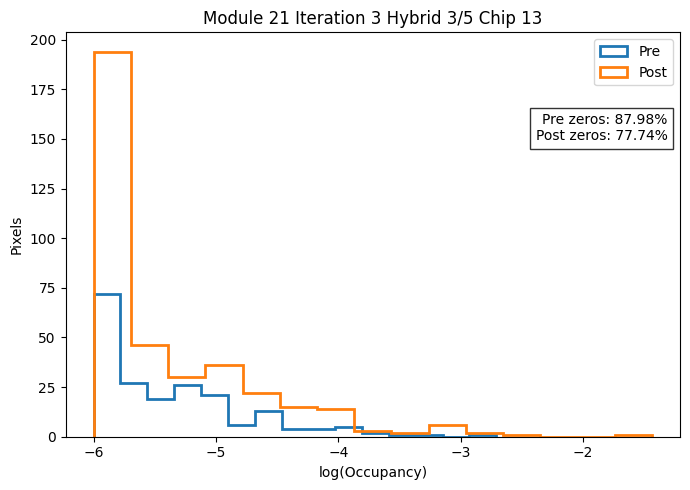


H3-C14
Pre zeros : 83.27%
Post zeros: 75.00%


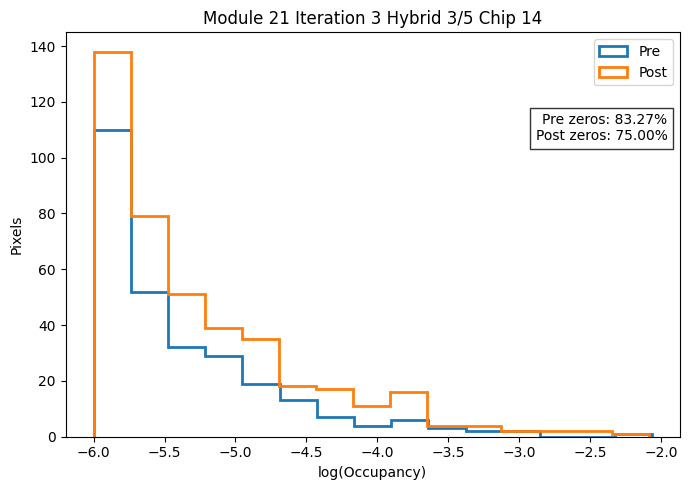


H3-C15
Pre zeros : 1.25%
Post zeros: 7.14%


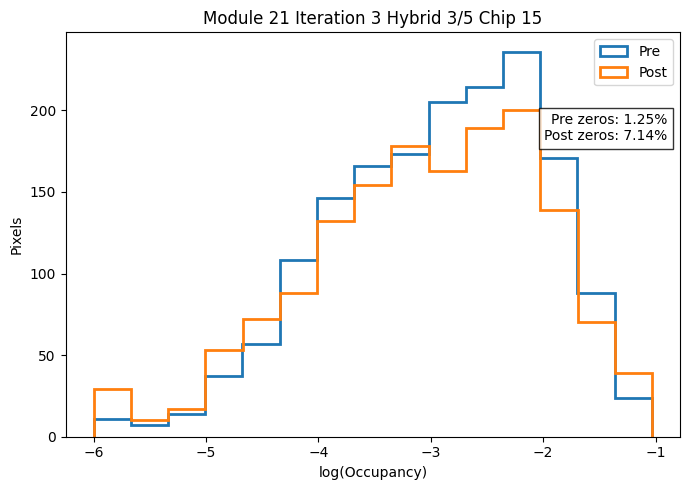

In [90]:
#Mod 21, Iteration 3

def make_post_histpath(hybrid, chip):
    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_2/Hybrid_{hybrid}/MPA_{chip}/"
        f"D_B(0)_O(2)_H({hybrid})_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

labels = []

for pre_hybrid, post_hybrid in zip([2,3],[4,5]):
    for chip in range(8,16):

        labels.append(f"H{pre_hybrid}-C{chip}")

        clean_pre, zero_pre = process_chip(
            root_pre,
            make_pre_histpath(pre_hybrid, chip)
        )

        clean_post, zero_post = process_chip(
            root_post,
            make_post_histpath(post_hybrid, chip)
        )

        print(f"\nH{pre_hybrid}-C{chip}")
        print(f"Pre zeros : {zero_pre:.2f}%")
        print(f"Post zeros: {zero_post:.2f}%")

        plt.figure(figsize=(7,5))

        plt.hist(np.log10(clean_pre),
                 bins=15,
                 histtype="step",
                 linewidth=2,
                 label="Pre")
        

        plt.hist(np.log10(clean_post),
            bins=15,
            histtype="step",
            linewidth=2,
            label = "Post")

        plt.xlabel("log(Occupancy)")
        plt.ylabel("Pixels")
        plt.title(f"Module 21 Iteration 3 Hybrid {pre_hybrid}/{post_hybrid} Chip {chip}")

        plt.text(
            0.98,0.8,
            f"Pre zeros: {zero_pre:.2f}%\nPost zeros: {zero_post:.2f}%",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            bbox=dict(facecolor="white",alpha=0.8)
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


H10-C8
Pre zeros : 2.38%
Post zeros: 9.88%


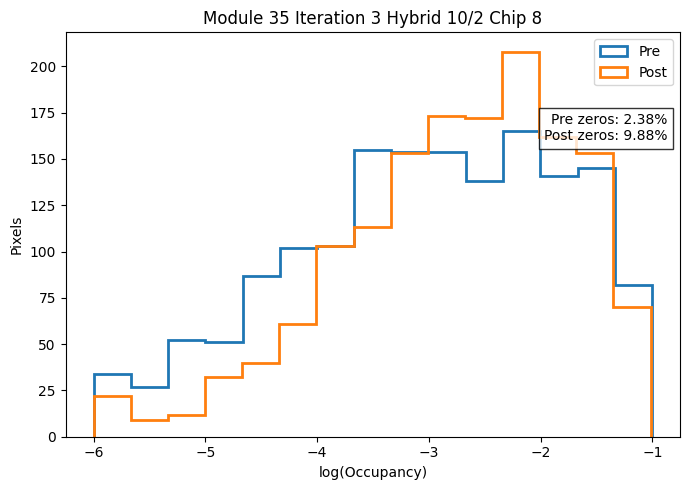


H10-C9
Pre zeros : 2.80%
Post zeros: 42.20%


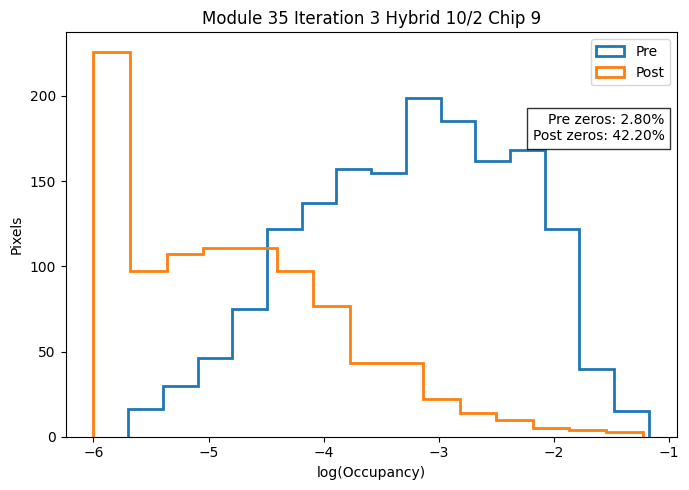


H10-C10
Pre zeros : 75.00%
Post zeros: 69.52%


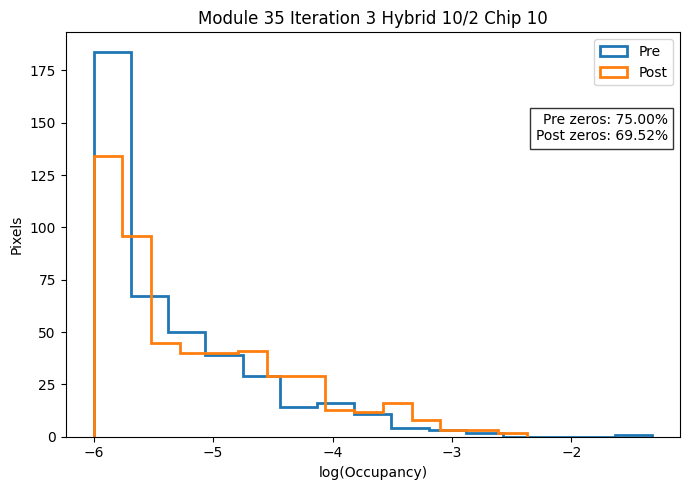


H10-C11
Pre zeros : 78.75%
Post zeros: 71.61%


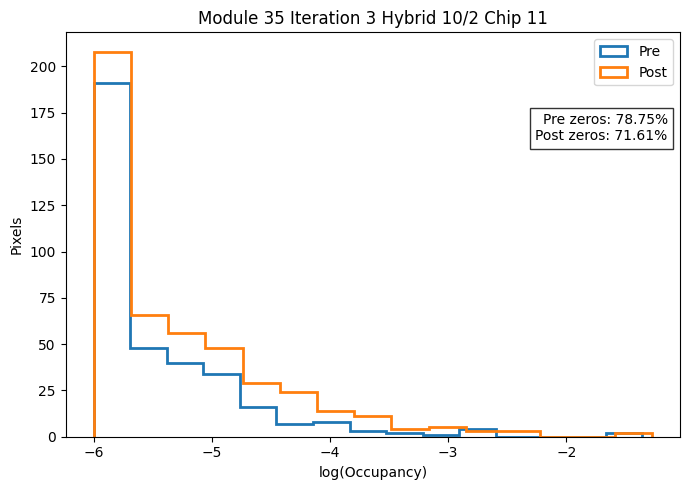


H10-C12
Pre zeros : 73.63%
Post zeros: 69.52%


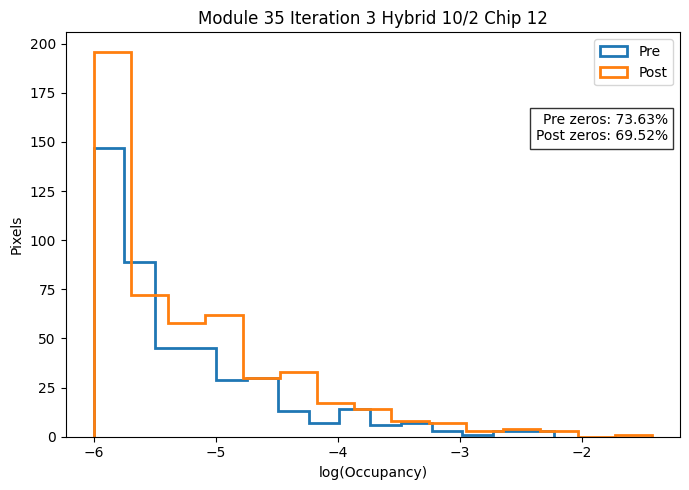


H10-C13
Pre zeros : 67.50%
Post zeros: 68.15%


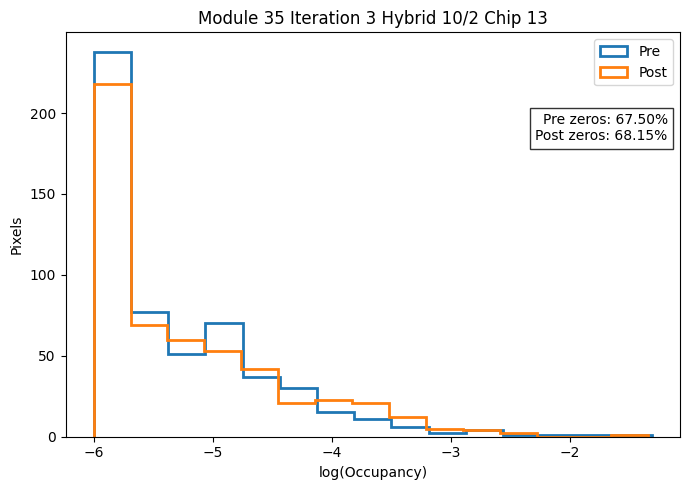


H10-C14
Pre zeros : 88.21%
Post zeros: 69.58%


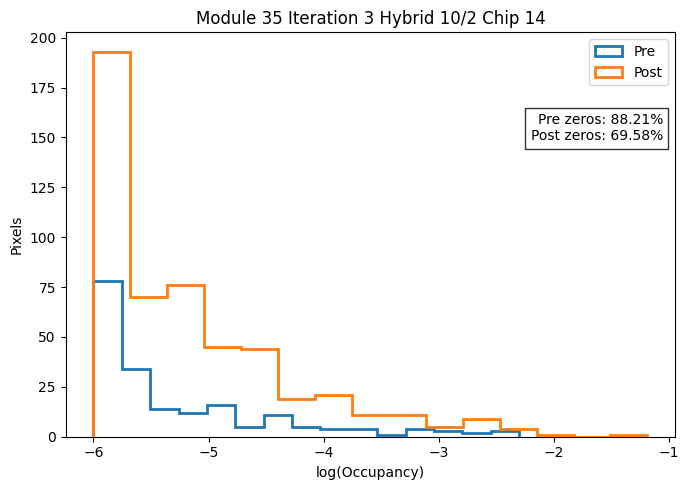


H10-C15
Pre zeros : 82.26%
Post zeros: 74.76%


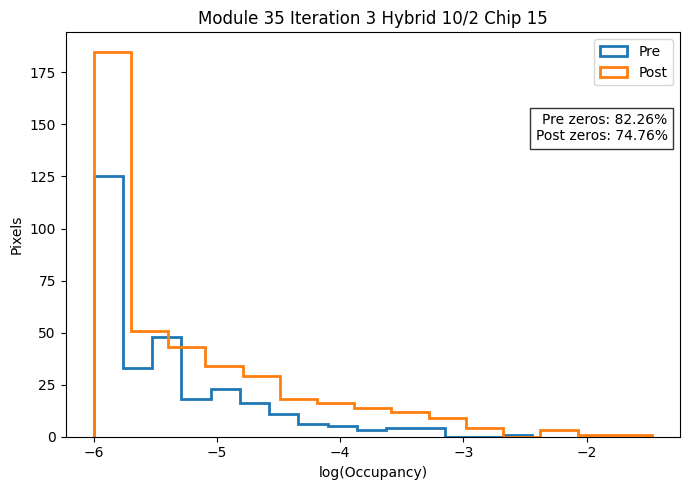


H11-C8
Pre zeros : 82.86%
Post zeros: 77.50%


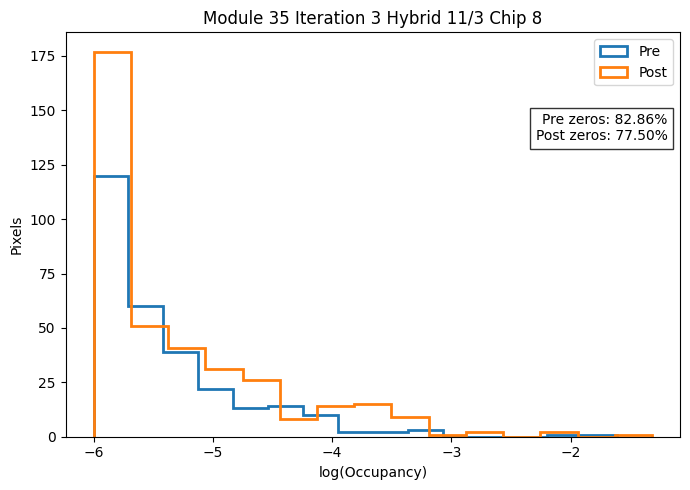


H11-C9
Pre zeros : 65.95%
Post zeros: 79.94%


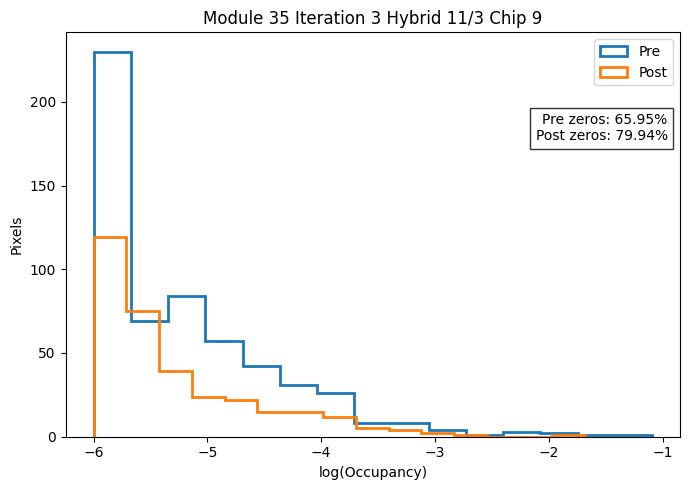


H11-C10
Pre zeros : 72.62%
Post zeros: 70.18%


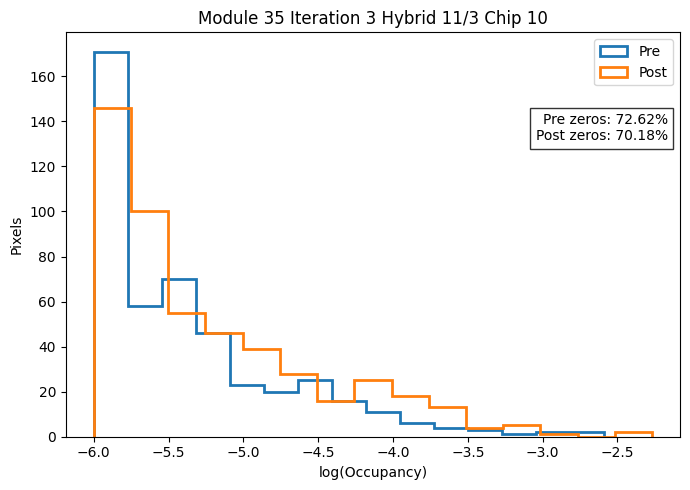


H11-C11
Pre zeros : 55.12%
Post zeros: 72.50%


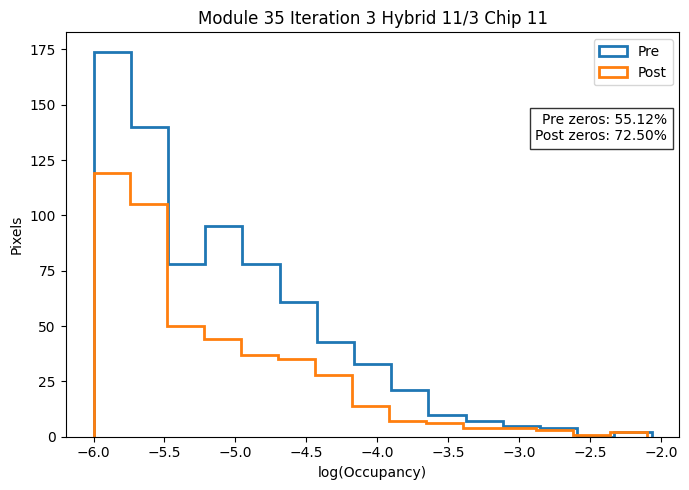


H11-C12
Pre zeros : 85.60%
Post zeros: 69.40%


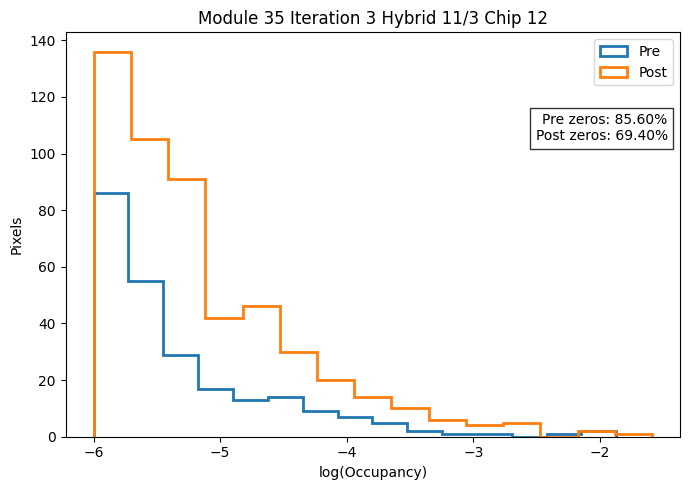


H11-C13
Pre zeros : 81.55%
Post zeros: 78.99%


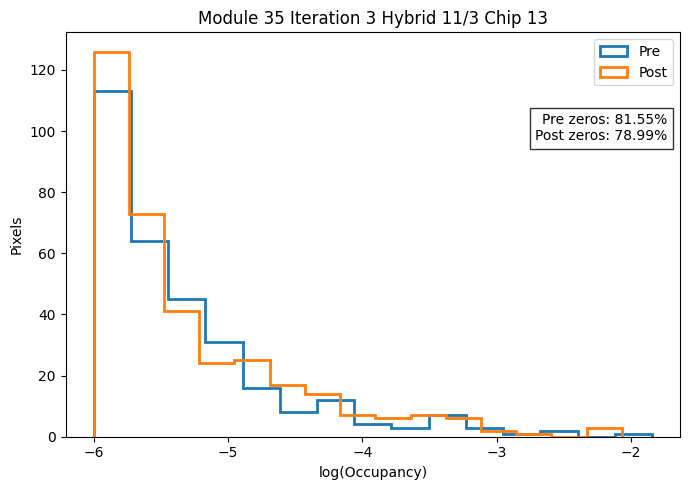


H11-C14
Pre zeros : 67.74%
Post zeros: 66.49%


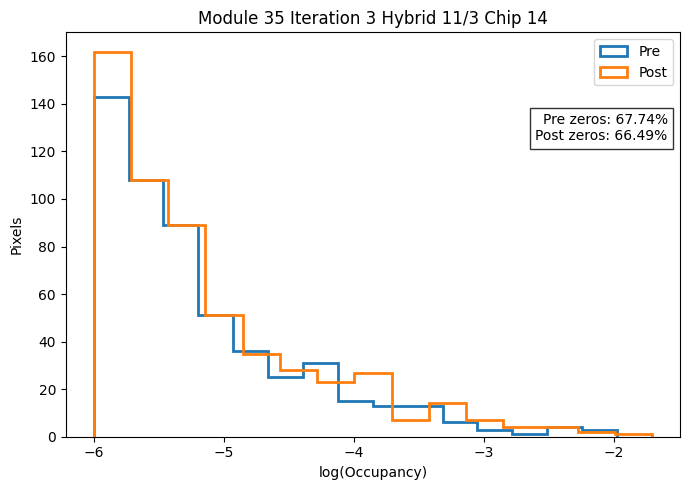


H11-C15
Pre zeros : 87.14%
Post zeros: 64.94%


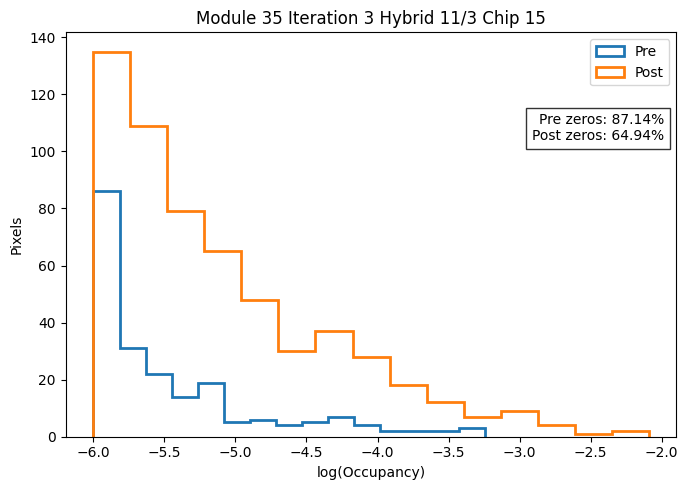

In [81]:
#Mod 35, Iteration 3

root_pre = "PS_16_FNL-10035_2025-12-02_04h37m52s_-33C_PSfullTest_v6-22.root"

def make_pre_histpath(hybrid, chip):
    return (
        f"Detector/Board_0/OpticalGroup_5/"
        f"Hybrid_{hybrid}/MPA_{chip}/"
        f"D_B(0)_O(5)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

def make_post_histpath(hybrid, chip):
    return (
        f"Iteration_3_PSfullTest_2026-03-13_08-45-57/"
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

labels = []

for pre_hybrid, post_hybrid in zip([10,11],[2,3]):
    for chip in range(8,16):

        labels.append(f"H{pre_hybrid}-C{chip}")

        clean_pre, zero_pre = process_chip(
            root_pre,
            make_pre_histpath(pre_hybrid, chip)
        )

        clean_post, zero_post = process_chip(
            root_post,
            make_post_histpath(post_hybrid, chip)
        )

        print(f"\nH{pre_hybrid}-C{chip}")
        print(f"Pre zeros : {zero_pre:.2f}%")
        print(f"Post zeros: {zero_post:.2f}%")

        plt.figure(figsize=(7,5))

        plt.hist(np.log10(clean_pre),
                 bins=15,
                 histtype="step",
                 linewidth=2,
                 label="Pre")

        plt.hist(np.log10(clean_post),
                 bins=15,
                 histtype="step",
                 linewidth=2,
                 label="Post")

        plt.xlabel("log(Occupancy)")
        plt.ylabel("Pixels")
        plt.title(f"Module 35 Iteration 3 Hybrid {pre_hybrid}/{post_hybrid} Chip {chip}")

        plt.text(
            0.98,0.8,
            f"Pre zeros: {zero_pre:.2f}%\nPost zeros: {zero_post:.2f}%",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            bbox=dict(facecolor="white",alpha=0.8)
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


H10-C8
Pre zeros : 2.38%
Post zeros: 9.64%


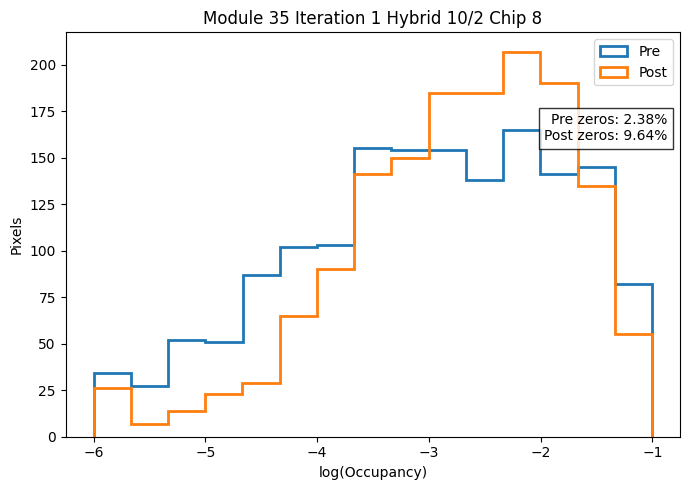


H10-C9
Pre zeros : 2.80%
Post zeros: 3.45%


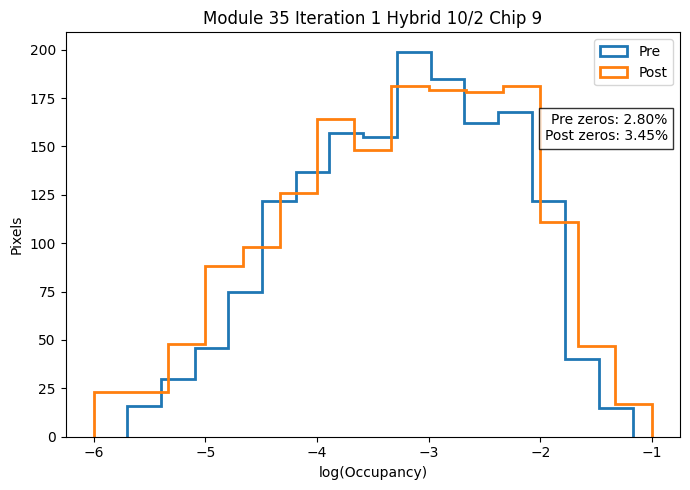


H10-C10
Pre zeros : 75.00%
Post zeros: 84.23%


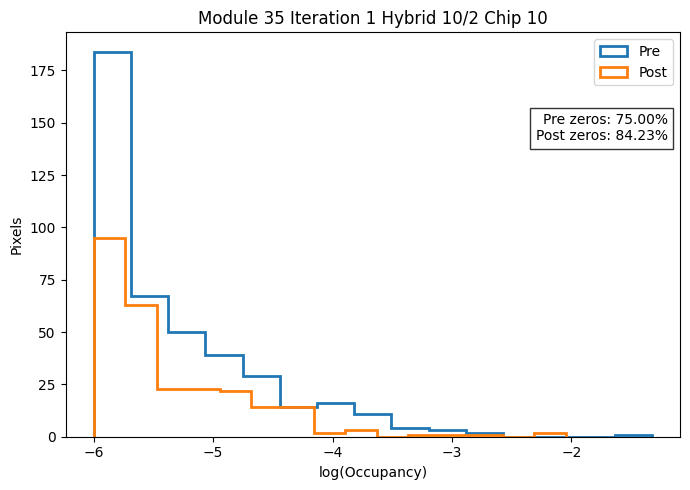


H10-C11
Pre zeros : 78.75%
Post zeros: 71.55%


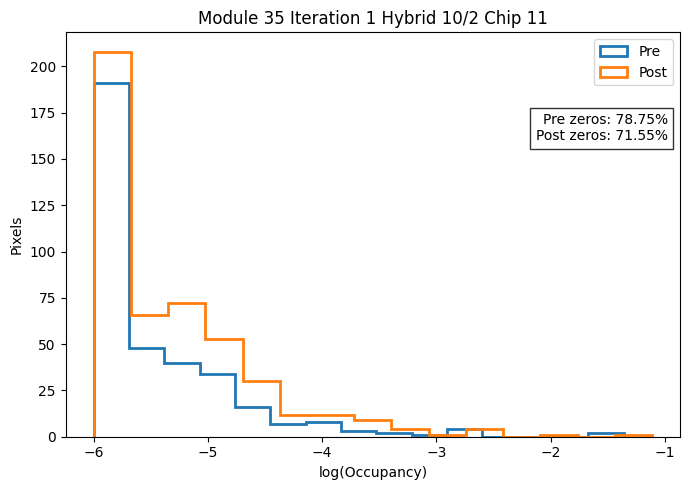


H10-C12
Pre zeros : 73.63%
Post zeros: 70.77%


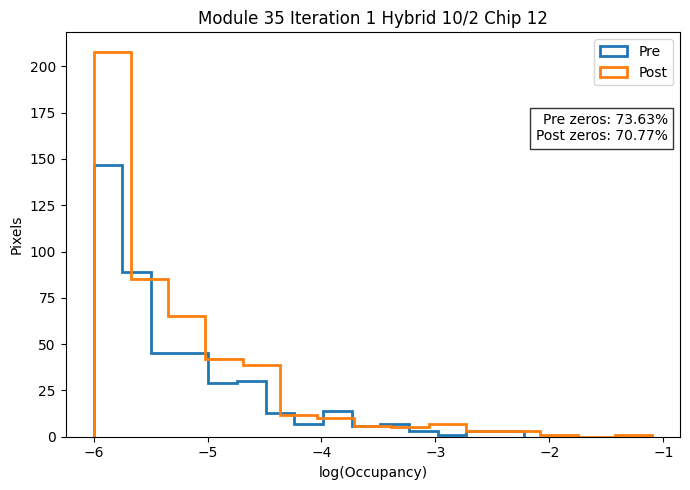


H10-C13
Pre zeros : 67.50%
Post zeros: 69.40%


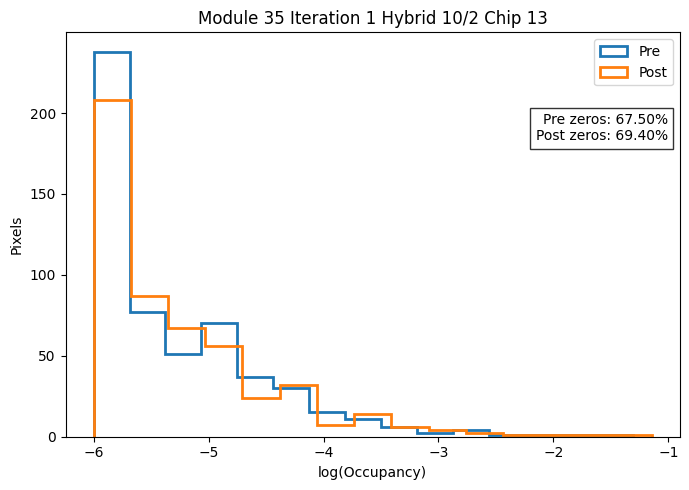


H10-C14
Pre zeros : 88.21%
Post zeros: 70.30%


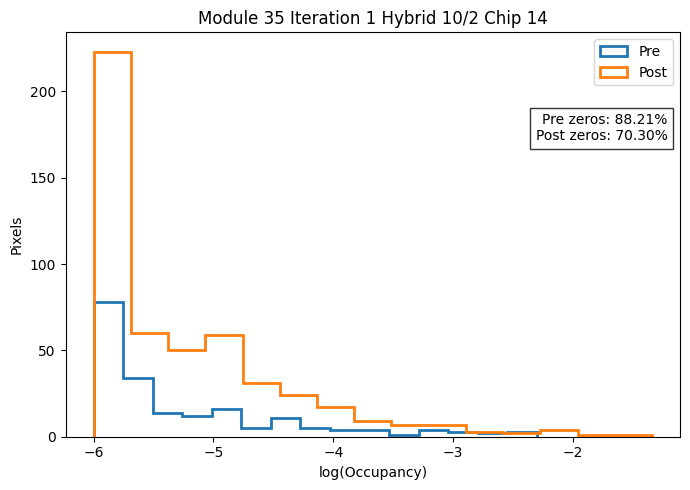


H10-C15
Pre zeros : 82.26%
Post zeros: 77.02%


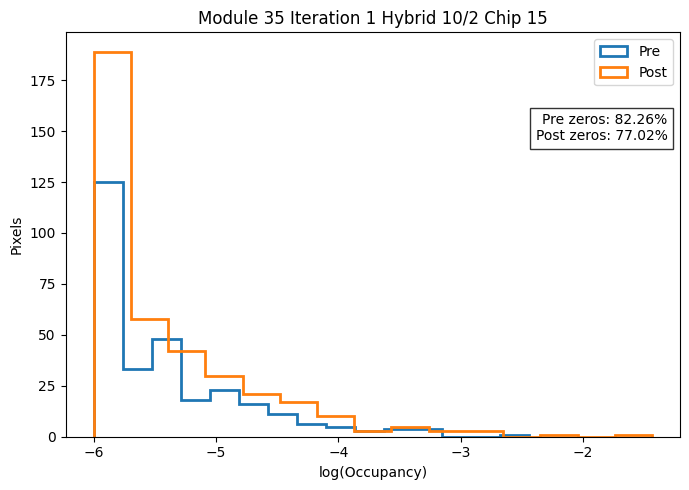


H11-C8
Pre zeros : 82.86%
Post zeros: 76.79%


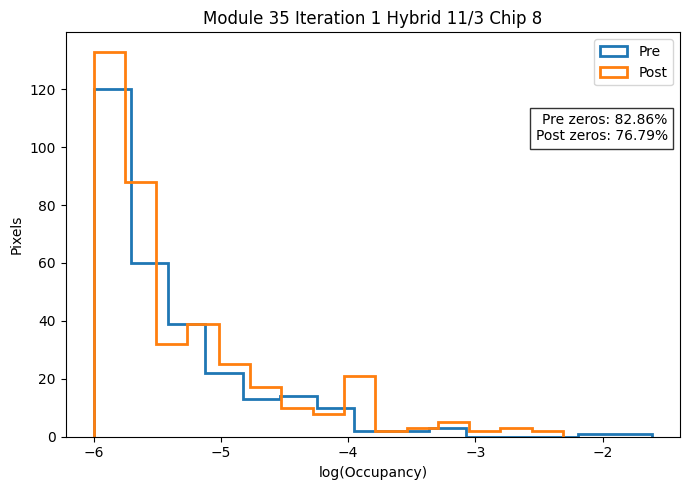


H11-C9
Pre zeros : 65.95%
Post zeros: 79.23%


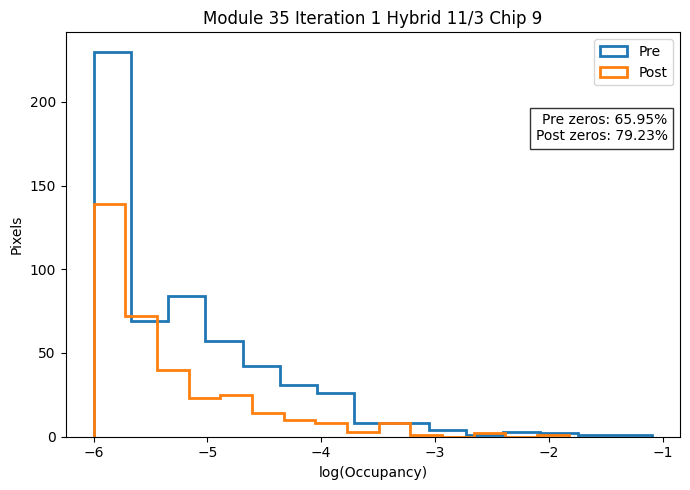


H11-C10
Pre zeros : 72.62%
Post zeros: 71.01%


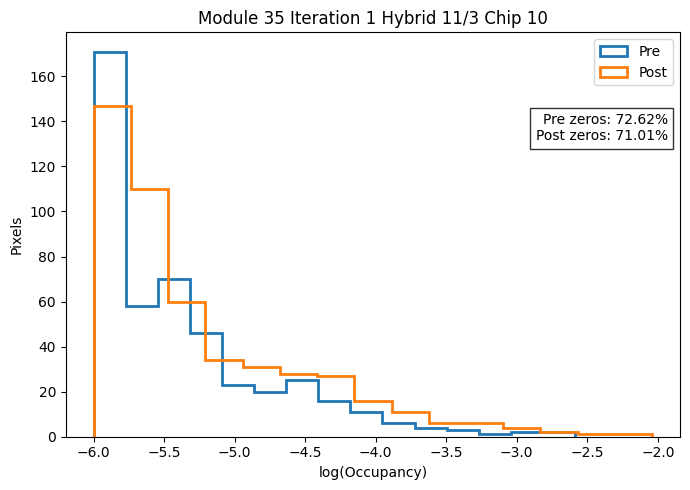


H11-C11
Pre zeros : 55.12%
Post zeros: 71.55%


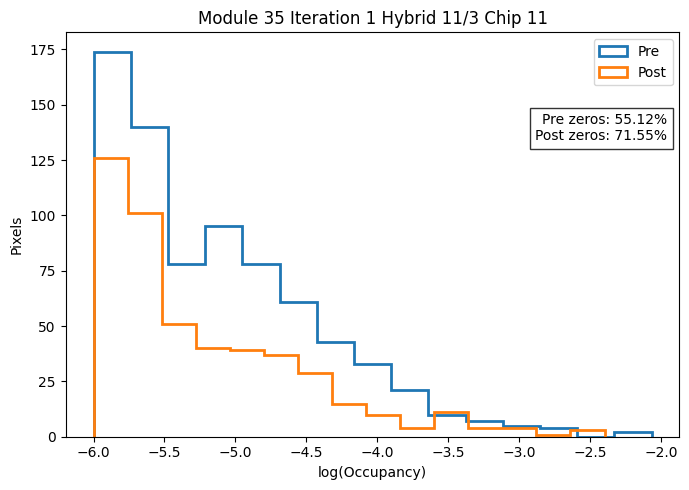


H11-C12
Pre zeros : 85.60%
Post zeros: 68.93%


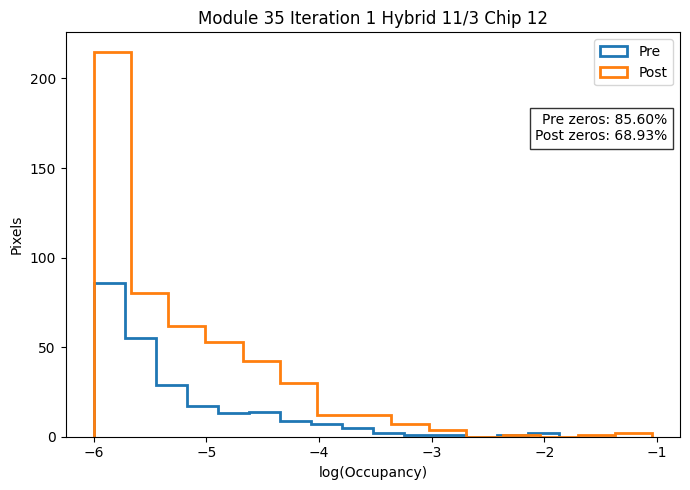


H11-C13
Pre zeros : 81.55%
Post zeros: 76.31%


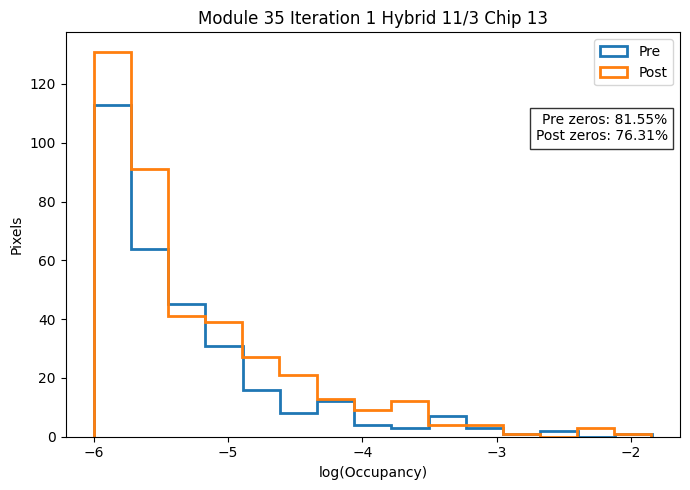


H11-C14
Pre zeros : 67.74%
Post zeros: 64.05%


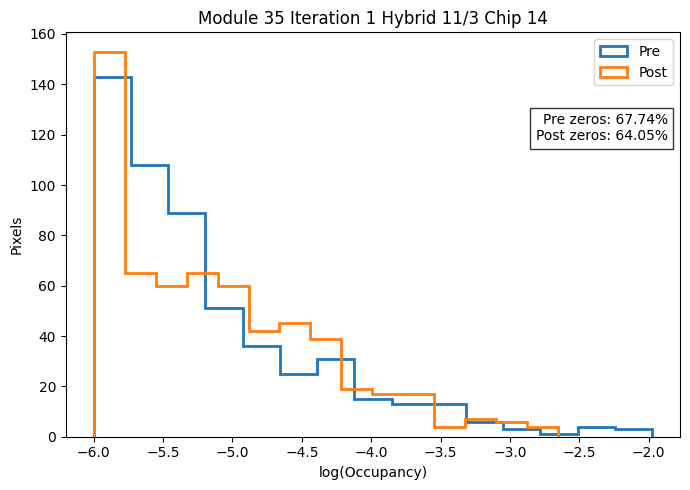


H11-C15
Pre zeros : 87.14%
Post zeros: 20.77%


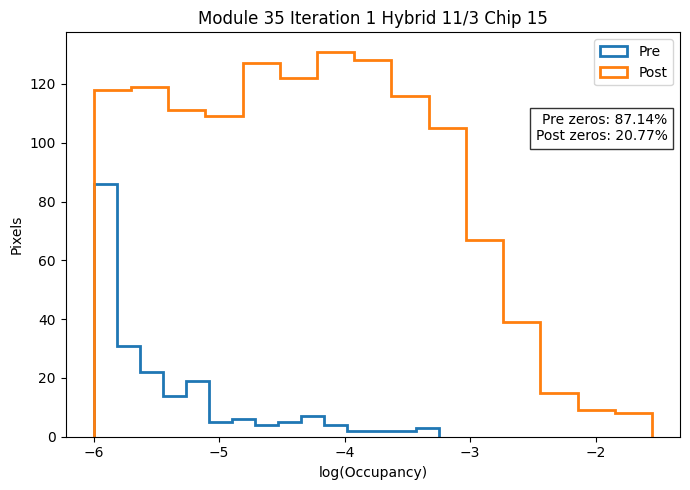

In [82]:
# Mod 35 Iteration 1

def make_post_histpath(hybrid, chip):
    return (
        f"Iteration_1_PSfullTest_2026-03-12_17-23-21/"
        f"Detector/Board_0/OpticalGroup_1/"
        f"Hybrid_{hybrid}/MPA_{chip}/"
        f"D_B(0)_O(1)_H({hybrid})"
        f"_ChannelOccupancy_Injection_0.000_MIP_Chip({chip});1"
    )

labels = []

for pre_hybrid, post_hybrid in zip([10,11],[2,3]):
    for chip in range(8,16):

        labels.append(f"H{pre_hybrid}-C{chip}")

        clean_pre, zero_pre = process_chip(
            root_pre,
            make_pre_histpath(pre_hybrid, chip)
        )

        clean_post, zero_post = process_chip(
            root_post,
            make_post_histpath(post_hybrid, chip)
        )

        print(f"\nH{pre_hybrid}-C{chip}")
        print(f"Pre zeros : {zero_pre:.2f}%")
        print(f"Post zeros: {zero_post:.2f}%")

        plt.figure(figsize=(7,5))

        plt.hist(np.log10(clean_pre),
                 bins=15,
                 histtype="step",
                 linewidth=2,
                 label="Pre")

        plt.hist(np.log10(clean_post),
                 bins=15,
                 histtype="step",
                 linewidth=2,
                 label="Post")

        plt.xlabel("log(Occupancy)")
        plt.ylabel("Pixels")
        plt.title(f"Module 35 Iteration 1 Hybrid {pre_hybrid}/{post_hybrid} Chip {chip}")

        plt.text(
            0.98,0.8,
            f"Pre zeros: {zero_pre:.2f}%\nPost zeros: {zero_post:.2f}%",
            transform=plt.gca().transAxes,
            ha="right",
            va="top",
            bbox=dict(facecolor="white",alpha=0.8)
        )

        plt.legend()
        plt.tight_layout()
        plt.show()